# Part 0: Download the data

In [ ]:
!wget "https://zenodo.org/records/20433262/files/data.tar.gz?download=1" -O data.tar.gz
!tar -xzvf data.tar.gz
!rm data.tar.gz

# Part 1: Load the ABUS model

In [1]:
import os
import torch
import numpy as np
import pandas as pd
from time import time
from tqdm import tqdm
from utils.utils import *
from model.ABUS import ABUS
from utils.dataset import ABUS_Dataset
from torch.utils.data import DataLoader
from model.ViT_pytorch import get_ml_config

In [2]:
config = {
    # model config
    "model_dir": "./save_model",
    "model_name": "ABUS",
    "data_dir": "./data/test_data",
    "result_dir": "./data/test_result",
    "others_dir": "./data/others",
    "img_dir": "./data/img"
}
os.makedirs(config["result_dir"], exist_ok=True)
os.makedirs(config["img_dir"], exist_ok=True)


params = {
    # Model Configuration    
    # Common
    'hidden_size': 16,
    'img_size': 32,
    'patch_size': 4,
    
    # Swin
    'window_size': 4,
    'swin_depths': [2, 2],
    'swin_num_heads': [4, 8],
    'drop_path_rate': 0.1,
    'shift_size': 2,
    'use_relative_position_bias': True,
    
    # Encoder   
    'dim_head': 16,
    'dropout': 0,
    'attn_dropout': 0,
    'n_heads': 8,
    'transformer_depth': 8,
    
    # Train Configuration
    'seed': 7272,
    'temperature': 0.5,
    'margin': 0,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

model_colors = {
    "ANTIPASTI": '#A0BBD7',
    "CSM-AB": '#D7D7D9',
    "HADDOCK": '#AEBAB1',
    "ZRANK2": '#CCC0DA',
    "PIsToN": '#D8D0C3',
    "ABUS": '#4E6C97'
}
metrics_names = ['ROC-AUC', 'PR-AUC', 'Balanced Accuracy', 'F1-score', 'Precision', 'Recall']

set_seed(params['seed'])
model_config = get_ml_config(params)
device = params['device']
model = ABUS(model_config, img_size=params['img_size'], margin=params['margin'], temperature=params['temperature']).float()
model = model.to(device)
model.eval() 
model.load_state_dict(torch.load(os.path.join(config["model_dir"], f"{config['model_name']}.pth"), map_location=device))
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
n_params = sum([np.prod(p.size()) for p in model_parameters])
log_info("Model Log", f"Load model {config['model_name']} with {n_params} parameters.")

[2026-05-29 05:56:16][Model Log] Load model ABUS with 89880 parameters.


# Part 2: SAbDab Test Dataset

## Create Dataset and DataLoader

In [3]:
SAbDab_GRID_DIR = os.path.join(config["data_dir"], "SAbDab", "npy")
ppi_list = os.listdir(SAbDab_GRID_DIR)
ppi_list = [x.split('.npy')[0] for x in ppi_list]
labels = [0 if 'neg' in x else 1 for x in ppi_list]
log_info("SAbDab Log", f"Extracted {len(ppi_list)} SAbDab complexes.")
log_info("SAbDab Log", f"{np.sum(labels)} acceptable and {len(labels) -np.sum(labels)} incorrect.")
sabdab_test_dataset = ABUS_Dataset(SAbDab_GRID_DIR, ppi_list)
sabdab_test_loader = DataLoader(sabdab_test_dataset, batch_size=1, shuffle=False, pin_memory=False)

[2026-05-29 05:56:35][SAbDab Log] Extracted 1492 SAbDab complexes.
[2026-05-29 05:56:35][SAbDab Log] 746 acceptable and 746 incorrect.
[2026-05-29 05:56:43][Dataset Log] Total shape of grids: (1492, 13, 32, 32)


## Infer

In [4]:
start = time()
torch.set_num_threads(1)

all_outputs = []
all_attn = []
predicted_labels = []

with torch.no_grad():
    for grid in tqdm(sabdab_test_loader):
        grid = grid.to(device)
        output, attn = model(grid)
        all_outputs.append(output)
        all_attn.append(attn)
        if float(output)<0:
            predicted_labels.append(1)
        else:
            predicted_labels.append(0)
            
output = torch.cat(all_outputs, axis=0)
log_info("SAbDab Log", f"Total inference time: {time() - start} sec")
pred_probabilities = output.cpu().detach().numpy()
all_ppis = ppi_list
out_file = os.path.join(config["result_dir"], f"{config['model_name']}_SAbDab_scores.csv")
with open(out_file, 'w') as out:
    out.write("PPI,score,label\n")
    for i in range(len(pred_probabilities)):
        out.write(f"{all_ppis[i]},{pred_probabilities[i]},{labels[i]}\n")
log_info("SAbDab Log", f"Save scores to {out_file}")

100%|██████████| 1492/1492 [00:54<00:00, 27.45it/s]

[2026-05-29 05:58:06][SAbDab Log] Total inference time: 54.47968077659607 sec
[2026-05-29 05:58:06][SAbDab Log] Save scores to ./data/test_result/ABUS_SAbDab_scores.csv


## Metrics

In [5]:
sabdab_df = pd.read_csv(out_file)
metrics = compute_all_metrics(sabdab_df)
metrics_data = {}
metrics_data[config["model_name"]] = metrics
roc_auc, prauc, balanced_accuracy, f1_score, precision, recall = metrics
log_info("SAbDab Log", f"ROC-AUC: {roc_auc:.4f}, PR-AUC: {prauc:.4f}, Balanced Accuracy: {balanced_accuracy:.4f}, F1-score: {f1_score:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

[2026-05-29 05:58:15][SAbDab Log] ROC-AUC: 0.9610, PR-AUC: 0.9549, Balanced Accuracy: 0.9021, F1-score: 0.9031, Precision: 0.8947, Recall: 0.9115


## Comparision with other models

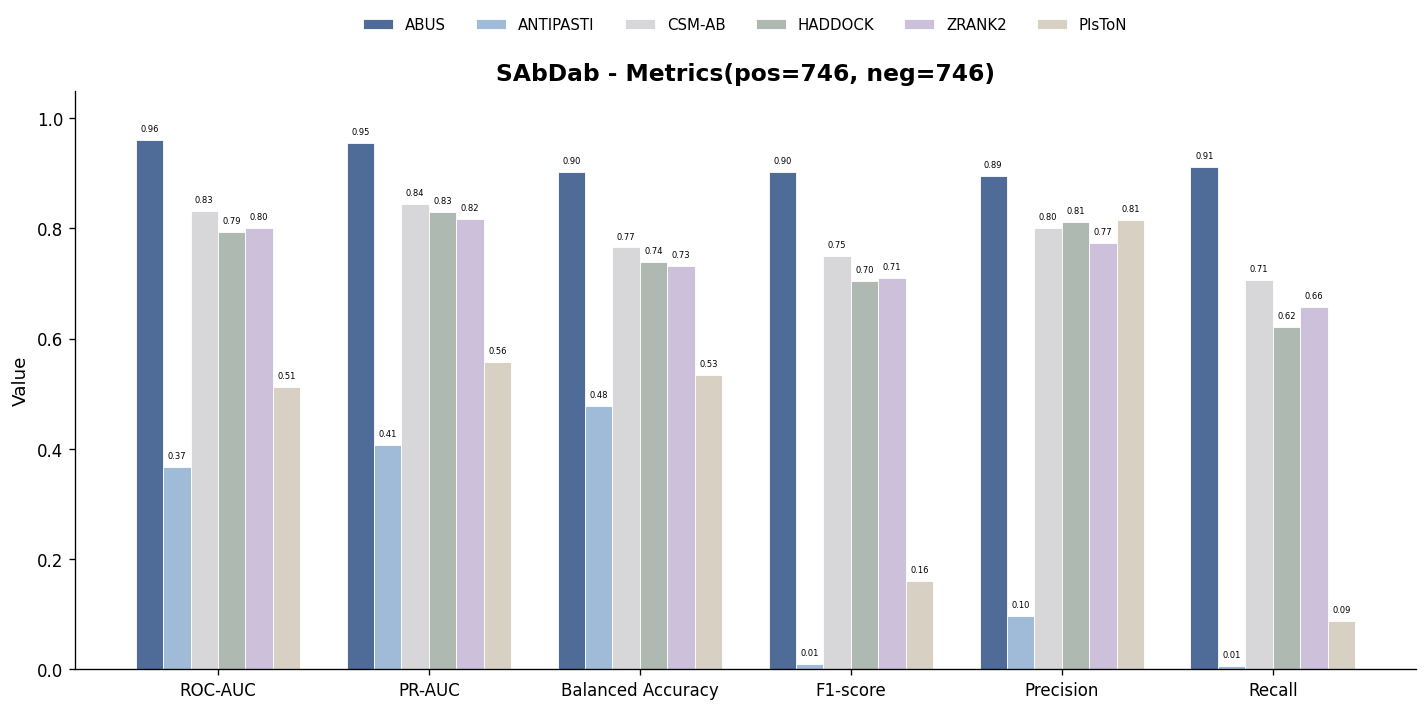

[2026-05-29 05:58:51][Plot Log] Saved to ./data/img/SAbDab_bar_metrics.png


In [6]:
SAbDab_Others = {
    "ANTIPASTI": os.path.join(config["others_dir"], "SAbDab", "antipasti_scores.csv"),
    "CSM-AB": os.path.join(config["others_dir"], "SAbDab", "csm_ab_scores.csv"),
    "HADDOCK": os.path.join(config["others_dir"], "SAbDab", "haddock_scores.csv"),
    "ZRANK2": os.path.join(config["others_dir"], "SAbDab", "zrank2_scores.csv"),
    "PIsToN": os.path.join(config["others_dir"], "SAbDab", "piston_scores.csv")   
}

for key, value in SAbDab_Others.items():
    df = pd.read_csv(value)
    metrics_data[key] = compute_all_metrics(df)

plot_bar(
    dataset = "SAbDab",
    pos_count = np.sum(labels),
    neg_count = len(labels) - np.sum(labels),
    model_list = metrics_data.keys(),
    metrics_data = metrics_data,
    metrics_names = metrics_names,
    model_colors = model_colors,
    out_dir = config["img_dir"],
)

# Part3: PDB2026 Dataset

In [7]:
PDB2026_GRID_DIR = os.path.join(config["data_dir"], "PDB2026", "npy")
ppi_list = os.listdir(PDB2026_GRID_DIR)
ppi_list = [x.split('.npy')[0] for x in ppi_list]
labels = [0 if 'neg' in x else 1 for x in ppi_list]
log_info("PDB2026 Log", f"Extracted {len(ppi_list)} PDB2026 complexes.")
log_info("PDB2026 Log", f"{np.sum(labels)} acceptable and {len(labels) -np.sum(labels)} incorrect.")
pdb2026_test_dataset = ABUS_Dataset(PDB2026_GRID_DIR, ppi_list)
pdb2026_test_loader = DataLoader(pdb2026_test_dataset, batch_size=1, shuffle=False, pin_memory=False)

[2026-05-29 05:59:04][PDB2026 Log] Extracted 12700 PDB2026 complexes.
[2026-05-29 05:59:04][PDB2026 Log] 195 acceptable and 12505 incorrect.
[2026-05-29 06:00:51][Dataset Log] Total shape of grids: (12700, 13, 32, 32)


In [8]:
start = time()
torch.set_num_threads(1)

all_outputs = []
all_attn = []
predicted_labels = []

with torch.no_grad():
    for grid in tqdm(pdb2026_test_loader):
        grid = grid.to(device)
        output, attn = model(grid)
        all_outputs.append(output)
        all_attn.append(attn)
        if float(output)<0:
            predicted_labels.append(1)
        else:
            predicted_labels.append(0)
            
output = torch.cat(all_outputs, axis=0)
log_info("PDB2026 Log", f"Total inference time: {time() - start} sec")
pred_probabilities = output.cpu().detach().numpy()
all_ppis = ppi_list
out_file = os.path.join(config["result_dir"], f"{config['model_name']}_PDB2026_scores.csv")
with open(out_file, 'w') as out:
    out.write("PPI,score,label\n")
    for i in range(len(pred_probabilities)):
        out.write(f"{all_ppis[i]},{pred_probabilities[i]},{labels[i]}\n")
log_info("PDB2026 Log", f"Save scores to {out_file}")

100%|██████████| 12700/12700 [05:42<00:00, 37.08it/s]


[2026-05-29 06:06:53][PDB2026 Log] Total inference time: 342.83025765419006 sec
[2026-05-29 06:06:54][PDB2026 Log] Save scores to ./data/test_result/ABUS_PDB2026_scores.csv


In [9]:
pdb2026_df = pd.read_csv(out_file)
metrics = compute_all_metrics(pdb2026_df)
metrics_data = {}
metrics_data[config["model_name"]] = metrics
roc_auc, prauc, balanced_accuracy, f1_score, precision, recall = metrics
log_info("PDB2026 Log", f"ROC-AUC: {roc_auc:.4f}, PR-AUC: {prauc:.4f}, Balanced Accuracy: {balanced_accuracy:.4f}, F1-score: {f1_score:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")


[2026-05-29 06:07:26][PDB2026 Log] ROC-AUC: 0.9654, PR-AUC: 0.5491, Balanced Accuracy: 0.7969, F1-score: 0.6015, Precision: 0.6031, Recall: 0.6000


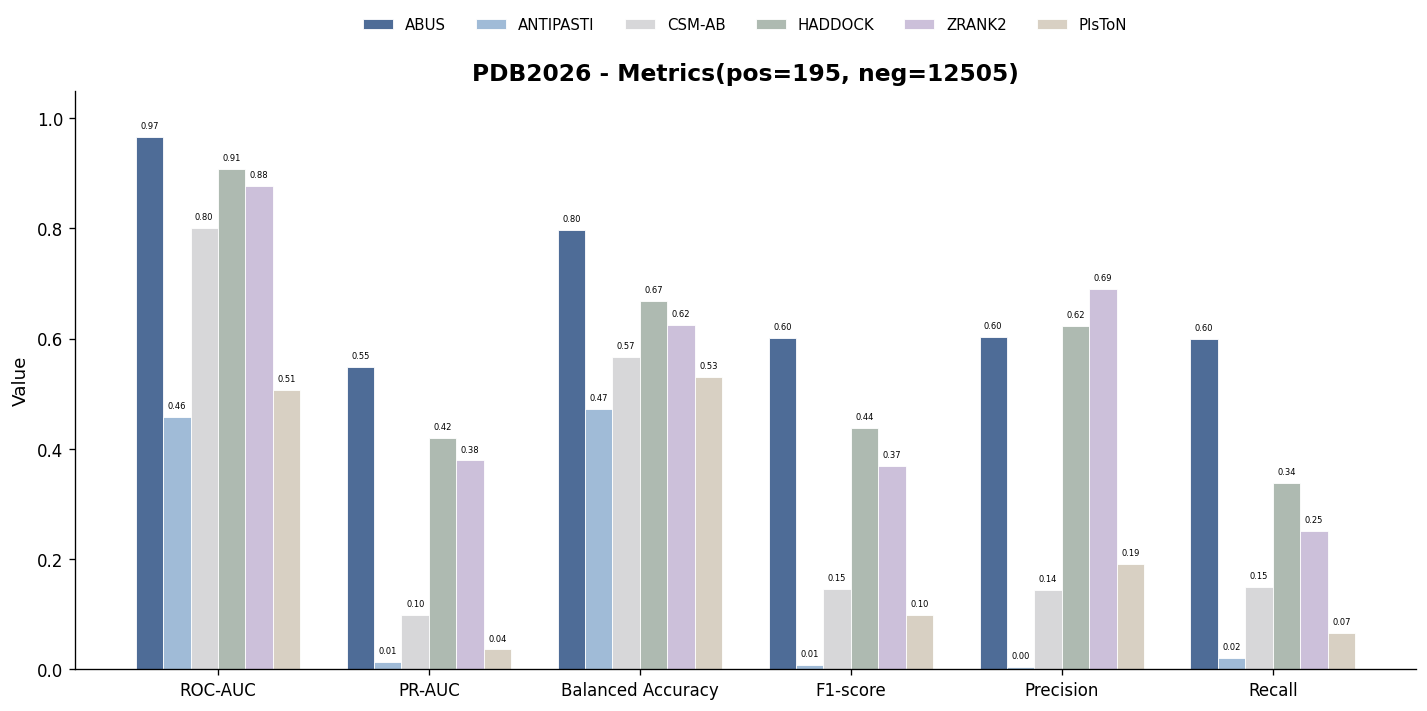

[2026-05-29 06:11:52][Plot Log] Saved to ./data/img/PDB2026_bar_metrics.png


In [10]:
PDB2026_Others = {
    "ANTIPASTI": os.path.join(config["others_dir"], "PDB2026", "antipasti_scores.csv"),
    "CSM-AB": os.path.join(config["others_dir"], "PDB2026", "csm_ab_scores.csv"),
    "HADDOCK": os.path.join(config["others_dir"], "PDB2026", "haddock_scores.csv"),
    "ZRANK2": os.path.join(config["others_dir"], "PDB2026", "zrank2_scores.csv"),
    "PIsToN": os.path.join(config["others_dir"], "PDB2026", "piston_scores.csv")   
}

for key, value in PDB2026_Others.items():
    df = pd.read_csv(value)
    metrics_data[key] = compute_all_metrics(df)

plot_bar(
    dataset = "PDB2026",
    pos_count = np.sum(labels),
    neg_count = len(labels) - np.sum(labels),
    model_list = metrics_data.keys(),
    metrics_data = metrics_data,
    metrics_names = metrics_names,
    model_colors = model_colors,
    out_dir = config["img_dir"],
)

[2026-05-29 06:12:03][Plot Log] Saved to ./data/img/PDB2026_topk_heatmap.png


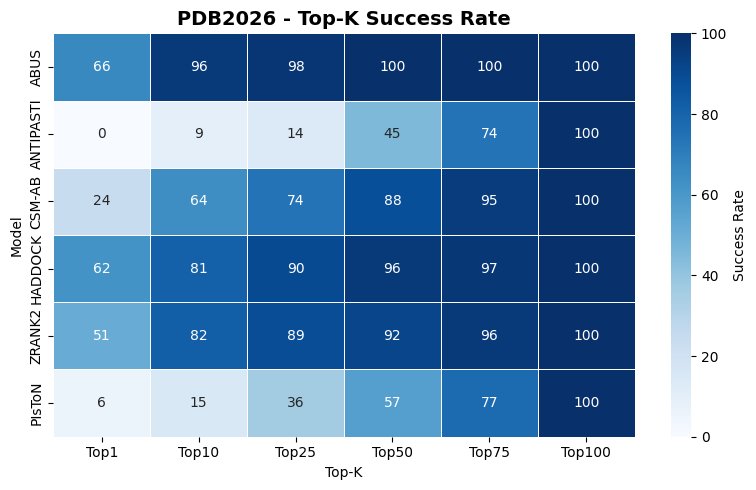

In [11]:
topk_matrix = []
topk = compute_success_rate(pdb2026_df, True)
topk_matrix.append(topk)
for key, value in PDB2026_Others.items():
    df = pd.read_csv(value)
    topk = compute_success_rate(df, True)
    topk_matrix.append(topk)
topk_matrix = np.array(topk_matrix) 
plot_topk_hot_map(topk_matrix, ["ABUS"] + list(PDB2026_Others.keys()), config["img_dir"], "PDB2026")

# Part4: Benchmark

In [12]:
ELISA_GRID_DIR = os.path.join(config["data_dir"], "ELISA-validated", "npy")
ppi_list = os.listdir(ELISA_GRID_DIR)
ppi_list = [x.split('.npy')[0] for x in ppi_list if "resname" not in x]

positive_sample = [ # These are ELISA validated positive samples.
    "abxhdock4090model2_HL_A",
    "abxzdock4090complex.1_HL_A",
    "abxzdock1255complex.3_HL_A",
    "rfantibody0464side_HL_T",
]

labels = [1 if x in positive_sample else 0 for x in ppi_list]
log_info("ELISA Log", f"Extracted {len(ppi_list)} ELISA complexes.")
log_info("ELISA Log", f"{np.sum(labels)} acceptable and {len(labels) -np.sum(labels)} incorrect.")
ELISA_test_dataset = ABUS_Dataset(ELISA_GRID_DIR, ppi_list)
ELISA_test_loader = DataLoader(ELISA_test_dataset, batch_size=1, shuffle=False, pin_memory=False)

[2026-05-29 06:12:35][ELISA Log] Extracted 40 ELISA complexes.
[2026-05-29 06:12:35][ELISA Log] 4 acceptable and 36 incorrect.
[2026-05-29 06:12:35][Dataset Log] Total shape of grids: (40, 13, 32, 32)


In [13]:
start = time()
torch.set_num_threads(1)

all_outputs = []
all_attn = []
predicted_labels = []

with torch.no_grad():
    for grid in tqdm(ELISA_test_loader):
        grid = grid.to(device)
        output, attn = model(grid)
        all_outputs.append(output)
        all_attn.append(attn)
        if float(output)<0:
            predicted_labels.append(1)
        else:
            predicted_labels.append(0)
            
output = torch.cat(all_outputs, axis=0)
log_info("ELISA Log", f"Total inference time: {time() - start} sec")
pred_probabilities = output.cpu().detach().numpy()
all_ppis = ppi_list
out_file = os.path.join(config["result_dir"], f"{config['model_name']}_ELISA-validated_scores.csv")
with open(out_file, 'w') as out:
    out.write("PPI,score,label\n")
    for i in range(len(pred_probabilities)):
        out.write(f"{all_ppis[i]},{pred_probabilities[i]},{labels[i]}\n")
ELISA_df = pd.read_csv(out_file)
ELISA_df = ELISA_df.sort_values(by="score", ascending=True).reset_index(drop=True)
ELISA_df.to_csv(out_file, index=False)
log_info("ELISA Log", f"Save scores to {out_file}")

100%|██████████| 40/40 [00:01<00:00, 29.26it/s]

[2026-05-29 06:13:19][ELISA Log] Total inference time: 4.119414329528809 sec
[2026-05-29 06:13:19][ELISA Log] Save scores to ./data/test_result/ABUS_ELISA-validated_scores.csv


[2026-05-29 06:13:53][Plot Log] Saved to ./data/img/ABUS_rank_score.png


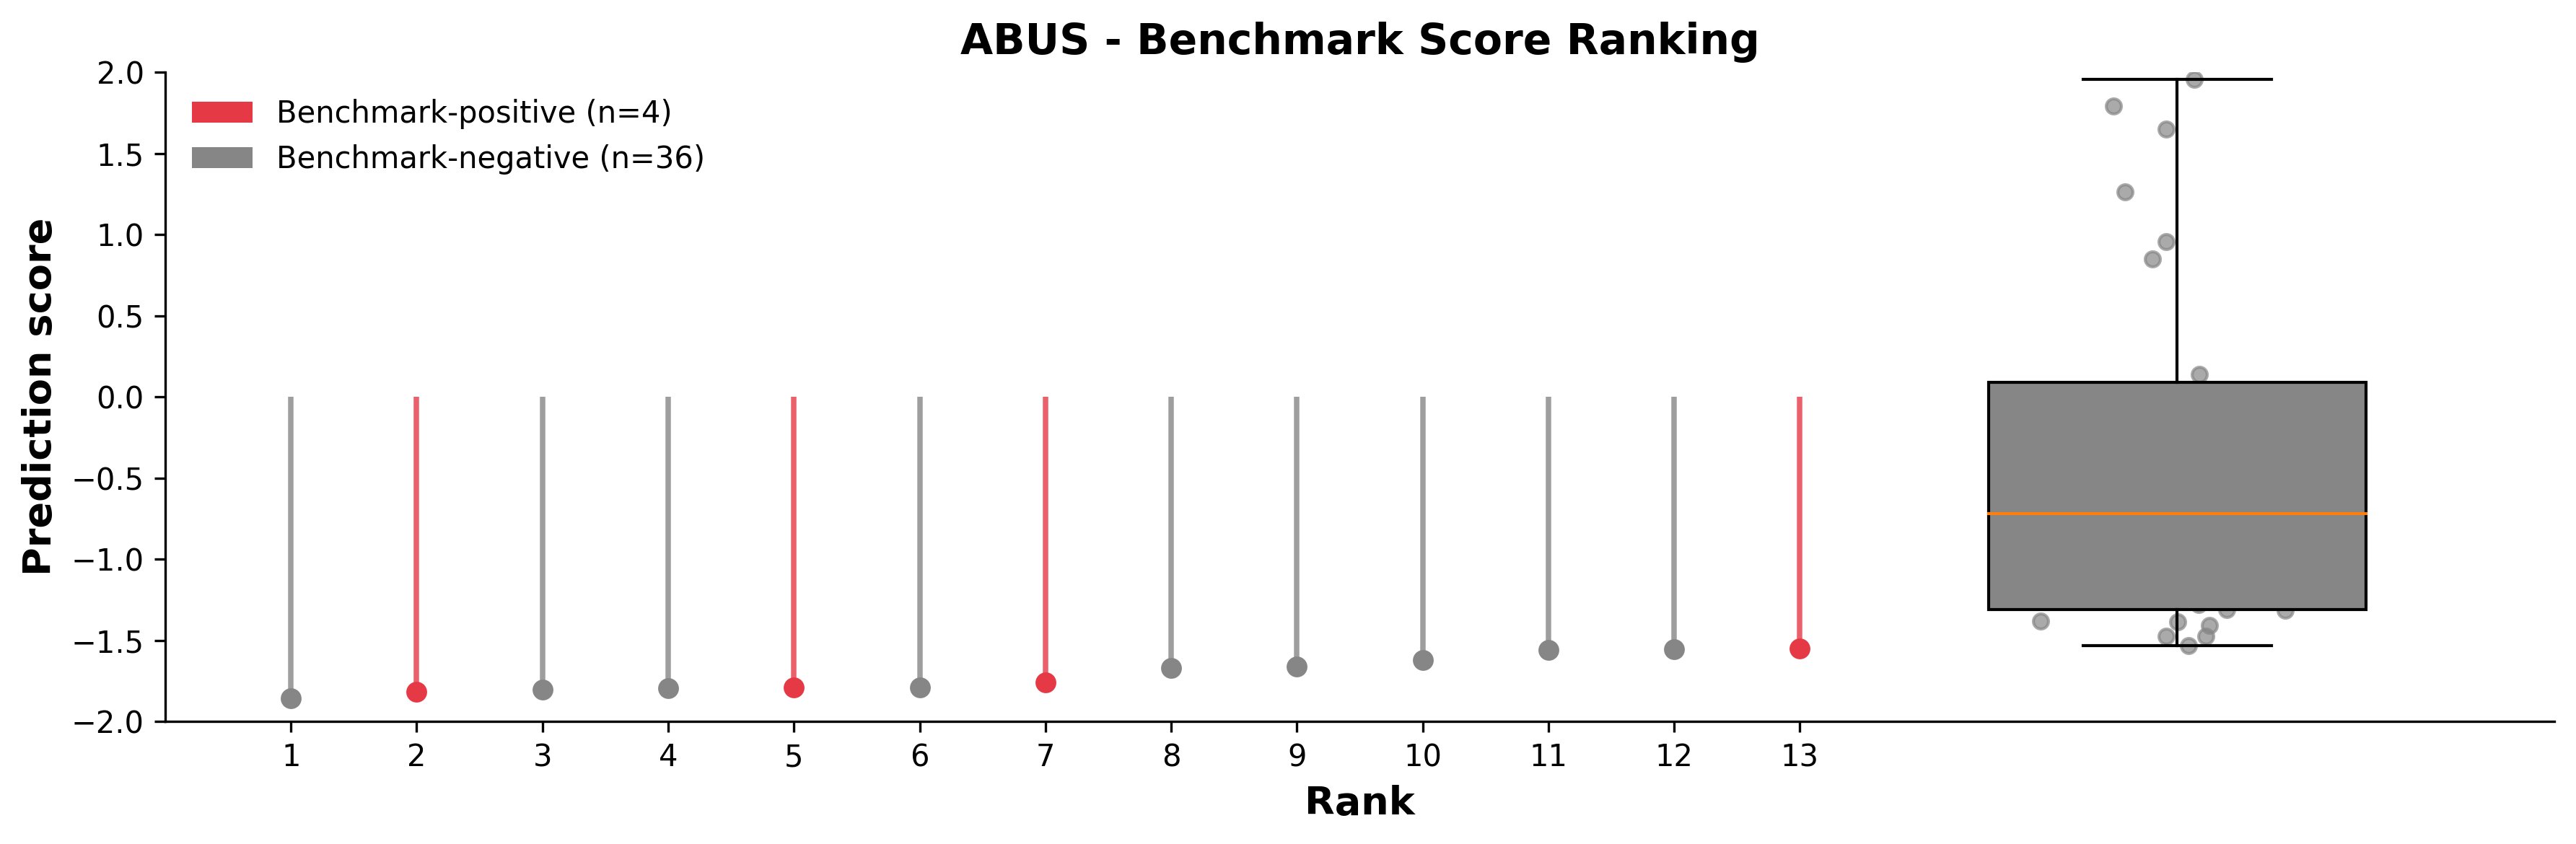

In [14]:
ELISA_df = pd.read_csv(out_file)
plot_rank(
    df= ELISA_df, 
    pos_count = np.sum(labels),
    neg_count = len(labels) - np.sum(labels),
    out_dir = config["img_dir"],
    model = "ABUS"
)